In [3]:
!pip install -U scikit-image

In [51]:
from skimage import exposure, color, filters, measure, morphology
from scipy.ndimage import convolve
from scipy.signal import convolve2d, medfilt2d
import numpy as np
import matplotlib.pyplot as plt
import time
import random

**Exercice 4.11** (Filtre moyenneur) Ouvrez l'image `Lenna.bmp`.

- **1)** Sur l'image, placez des pixels noirs non adjacents et ne touchant pas les bordures, soit à la main soit aléatoirement.
- **2)** Écrivez un programme qui remplace les points de l'image par la moyenne des 9 points voisins. Visualisez le résultat.
- **3)** Effectuez une opération similaire au moyen de l'instruction `signal.convolve2d(I, h, mode='same')` où `I` est l'image corrompue par les points noirs et `h` est une matrice de taille $3\times3$ dont toutes les entrées valent $1/9$. Visualisez le résultat. Que voit-on ?
- **4)** Recommencez l'opération avec une matrice `h` de taille $5\times5$ dont les entrées valent $1/25$. Visualisez le résultat. Quelles sont les différences avec celui du point précédent ?
- **5)** Écrivez un programme qui atténue les points noirs en effectuant une moyenne sur les 8 points voisins (en ne prenant pas en compte la valeur centrale, qui est celle du pixel noir). Visualisez le résultat. Est-il meilleur ? À quelle matrice `h` correspond cette opération ?
- **6)** Essayez d'améliorer ce filtre, par exemple en ne l'appliquant qu'aux points noirs « isolés », c'est-à-dire ceux pour lesquels la différence de valeur avec ses voisins dépasse un certain seuil.
- **7)** Appliquez un filtre médian (`signal.medfilt2d`) à l'image corrompue initiale et comparez le résultat avec celui obtenu via le filtre moyenneur.

#### 1) Placer des pixels noirs sur l'image

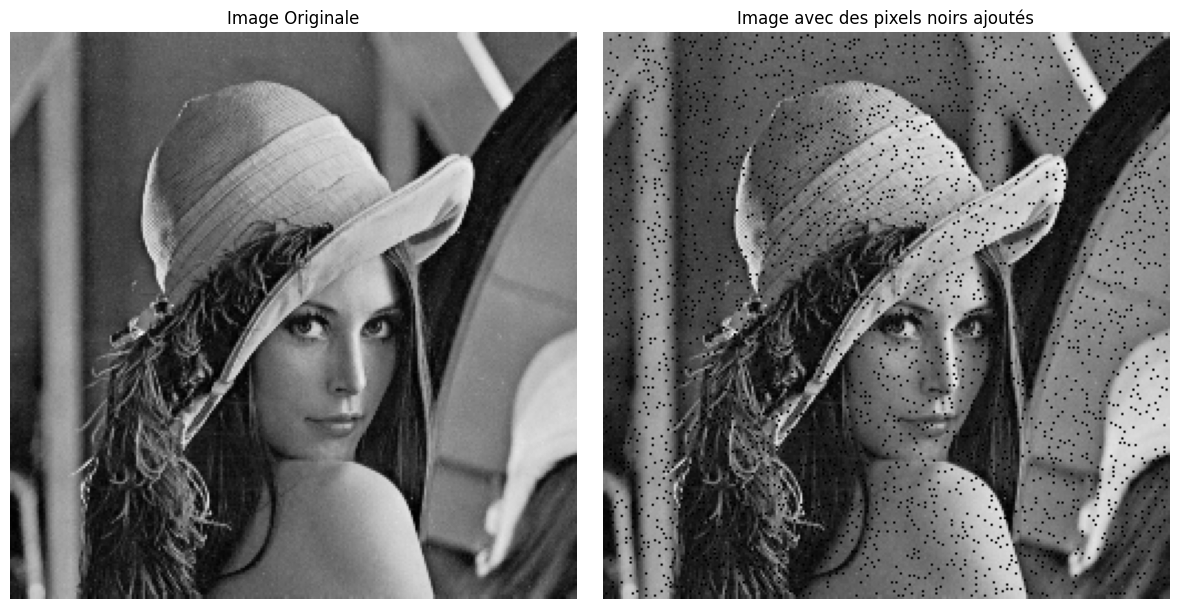

In [37]:
# 1. Chargé l'image
LennaImg = '../Fichiers-pour-TP/Image/LENNA.BMP'
lenna = plt.imread(LennaImg)

if len(lenna.shape) == 3:  # Vérifie si l'image est en couleur
    lenna_gray = color.rgb2gray(lenna)
    lenna_gray = (lenna_gray * 255).astype(np.uint8)
else:
    lenna_gray = lenna.copy()

# Dimensions de l'image 
height, width = lenna.shape

# Étape 2 : Ajouter des pixels noirs
# Nombre de pixels noirs à ajouter
num_pixels = 3000  # Vous pouvez ajuster ce nombre
min_dist = 1  # Distance minimale entre les pixels noirs

# Liste pour stocker les positions des pixels noirs
black_pixel_positions = []

while len(black_pixel_positions) < num_pixels:
    # Générer des coordonnées aléatoires
    x = random.randint(min_dist, height - min_dist - 1)
    y = random.randint(min_dist, width - min_dist - 1)

    # Vérifier que le pixel n'est pas adjacent à un autre pixel noir
    if all(abs(x - px) > min_dist or abs(y - py) > min_dist for px, py in black_pixel_positions):
        black_pixel_positions.append((x, y))

# Ajouter les pixels noirs à l'image
for x, y in black_pixel_positions:
    lenna_gray[x, y] = 0

# Étape 3 : Afficher l'image avec les pixels noirs
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(lenna, cmap='gray')
axes[0].set_title("Image Originale")
axes[0].axis('off')

axes[1].imshow(lenna_gray, cmap='gray')
axes[1].set_title("Image avec des pixels noirs ajoutés")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### 2) Appliquer filtre Moyenneur (première technique)

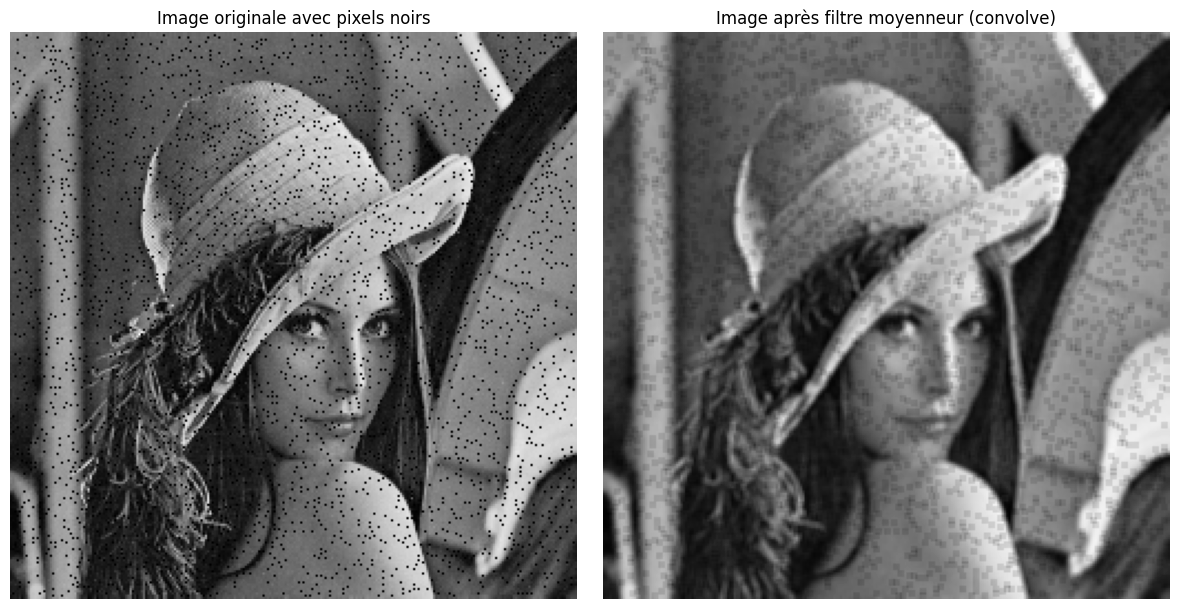

In [41]:
# Étape 2 : Définir le noyau moyenneur (3x3)
# kernel = np.ones((28, 28)) / 784
kernel = np.ones((3, 3)) / 9

# Étape 3 : Appliquer la convolution avec le noyau
smoothed_image = convolve(lenna_gray, kernel, mode='reflect')

# Étape 4 : Afficher l'image originale et filtrée
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lenna_gray, cmap='gray')
axes[0].set_title("Image originale avec pixels noirs")
axes[0].axis('off')

axes[1].imshow(smoothed_image, cmap='gray')
axes[1].set_title("Image après filtre moyenneur (ndimage.convolve)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### 3) et 4) Appliquer filtre Moyenneur (deuxième technique)
##### **Observations attendues**
- **Lissage des pixels noirs :**
  - Les pixels noirs (`artéfacts`) sont remplacés par la **moyenne** des **valeurs voisines**, ce qui les rend moins visibles.

- **Atténuation générale :**
  - L'image est globalement **lissée**, ce qui peut également diminuer la netteté des détails de l'image.

- **Différence par rapport à `ndimage.convolve` :**
  - Les deux fonctions donnent des résultats similaires, mais `signal.convolve2d` est plus explicite pour manipuler directement les matrices **ℎ** et **𝐼**.

- **Changement taille de matrice `h` :**
  - Un noyau **5x5** prends en compte les **25 pixels voisins** pour calculer la **moyenne**. Image **plus floue**. Meilleure **atténuation de bruit**.

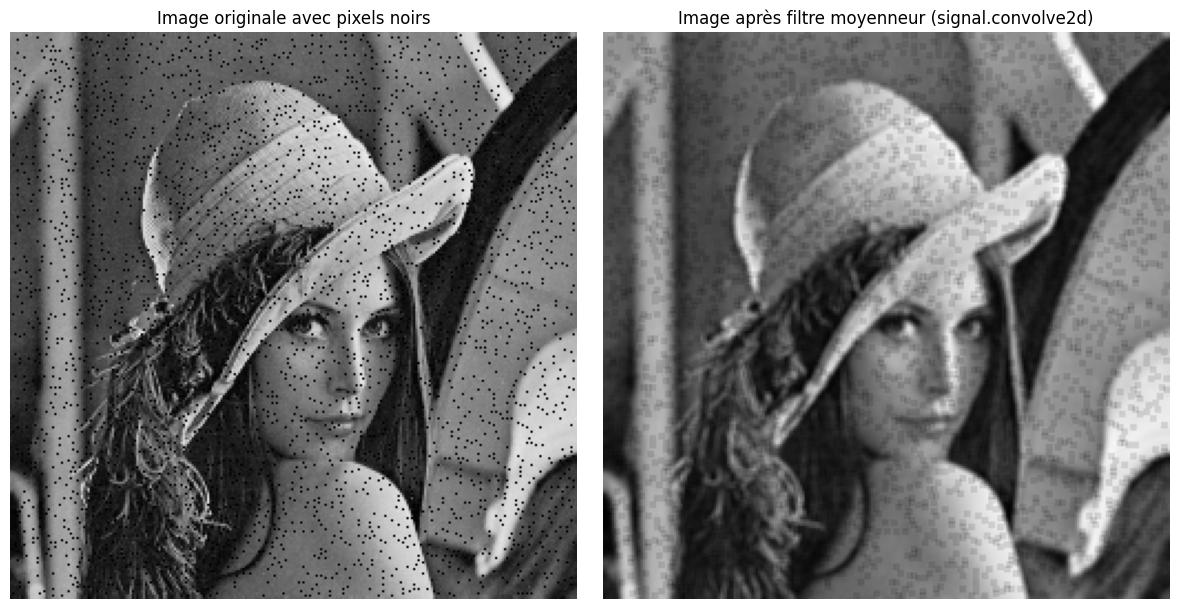

In [43]:
# Étape 2 : Définir le noyau moyenneur (3x3)
# kernel = np.ones((28, 28)) / 784
kernel = np.ones((3, 3)) / 9

# Étape 3 : Appliquer la convolution avec le noyau
smoothed_image2 = convolve2d(lenna_gray, kernel, mode='same', boundary='symm')

# Étape 4 : Afficher l'image originale et filtrée
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lenna_gray, cmap='gray')
axes[0].set_title("Image originale avec pixels noirs")
axes[0].axis('off')

axes[1].imshow(smoothed_image2, cmap='gray')
axes[1].set_title("Image après filtre moyenneur (signal.convolve2d)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#### 5) Atténuation points noirs
##### **Comparaison avec les méthodes précédentes**
- **Avantages :**
  - Cette méthode est plus ciblée, car elle ignore la valeur centrale, ce qui évite que les pixels noirs eux-mêmes biaisent le calcul.
  - Les pixels noirs seront mieux atténués sans "contaminer" la moyenne.

- **Inconvénients :**
  - Elle peut introduire des artefacts dans les zones où il y a des transitions de couleur importantes, car la valeur centrale n'est pas prise en compte.

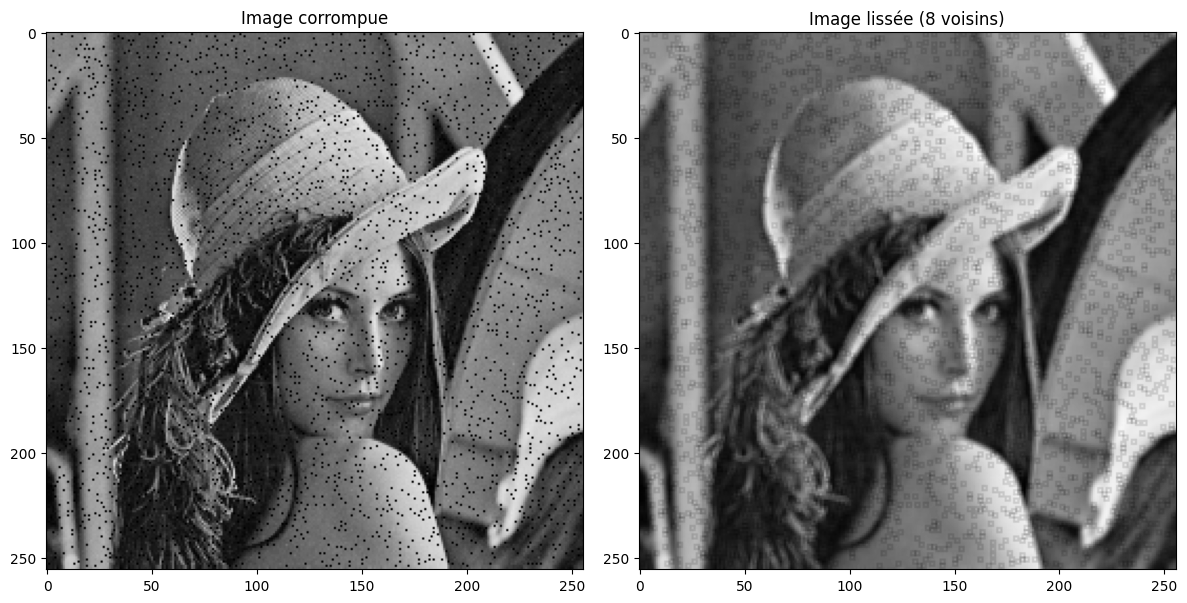

In [45]:
# Définir la matrice h (sans la valeur centrale)
h = np.array([[1, 1, 1],
              [1, 0, 1],
              [1, 1, 1]]) / 8  # Les 8 voisins contribuent également

# Appliquer la convolution
smoothed_image = convolve2d(lenna_gray, h, mode='same', boundary='symm')

# Visualiser les résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(lenna_gray, cmap='gray')
axes[0].set_title("Image corrompue")
axes[1].imshow(smoothed_image, cmap='gray')
axes[1].set_title("Image lissée (8 voisins)")
plt.tight_layout()
plt.show()

#### 6) Atténuation points noirs ciblé

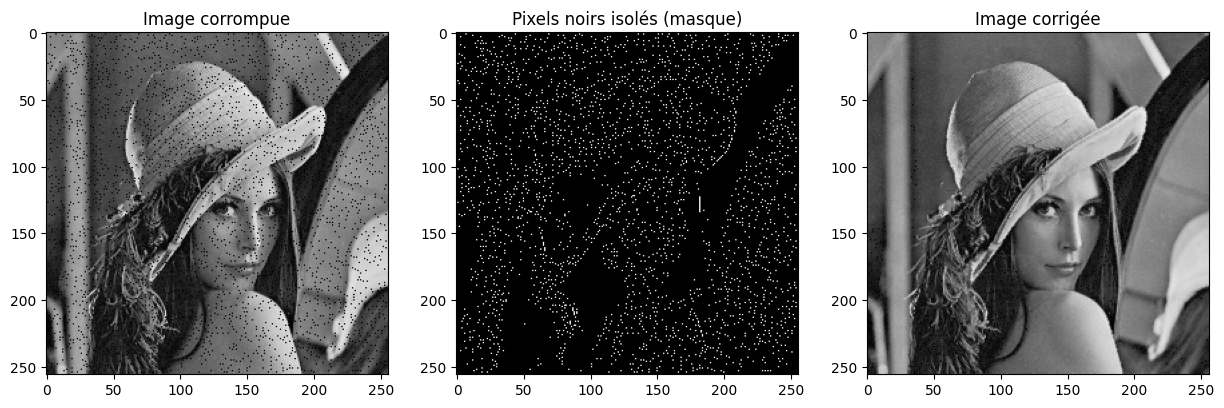

In [49]:
# Définir le filtre moyenneur pour 8 voisins
h = np.array([[1, 1, 1],
              [1, 0, 1],
              [1, 1, 1]]) / 8

# Calculer la moyenne locale (convolution)
local_mean = convolve2d(lenna_gray, h, mode='same', boundary='symm')

# Définir un seuil (par exemple, 50)
# threshold = 80  # Seuil trop haut : Peu de pixels seront corrigés, et certains pixels noirs isolés resteront visibles.
threshold = 50
# threshold = 10  # Seuil trop bas : Beaucoup de pixels seront considérés comme noirs isolés, ce qui peut altérer des zones de l'image non corrompues.

# Identifier les pixels noirs isolés
mask_black_isolated = (lenna_gray < (local_mean - threshold))

# Créer une copie de l'image pour le traitement
image_filtered = lenna_gray.copy()

# Remplacer uniquement les pixels noirs isolés par la moyenne des voisins
image_filtered[mask_black_isolated] = local_mean[mask_black_isolated]

# Visualiser les résultats
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(lenna_gray, cmap='gray')
axes[0].set_title("Image corrompue")
axes[1].imshow(mask_black_isolated, cmap='gray')
axes[1].set_title("Pixels noirs isolés (masque)")
axes[2].imshow(image_filtered, cmap='gray')
axes[2].set_title("Image corrigée")
plt.show()

#### 7) Filtre Médian
- **Filtre médian :**
  - Contrairement au filtre moyenneur, le filtre médian remplace chaque pixel par la médiane des pixels dans son voisinage.
  - Il est plus efficace pour supprimer les pixels isolés ou bruités tout en préservant les bords de l'image.

- Comparaison :
  - Le filtre moyenneur a tendance à flouter l'image, car il lisse les variations locales.
  - Le filtre médian conserve mieux les détails structurels, ce qui le rend adapté pour supprimer les points noirs tout en maintenant la netteté.

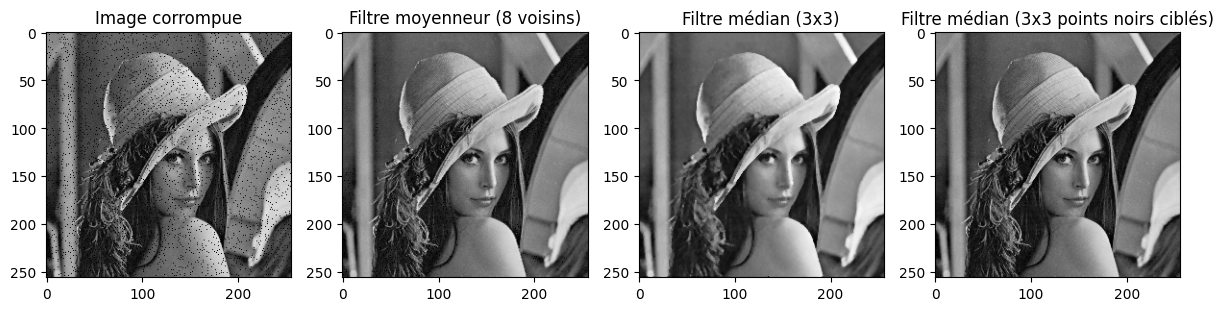

In [58]:
# Appliquer un filtre médian (fenêtre 3x3)
image_median_filtered = medfilt2d(lenna_gray, kernel_size=3)

# Remplacer uniquement les pixels noirs dans l'image corrompue
mask = (lenna_gray == 0)  # Identifier les points noirs
image_combined = lenna_gray.copy()
image_combined[mask] = image_median_filtered[mask]

# Afficher les résultats
fig, axes = plt.subplots(1, 4, figsize=(12, 6))

axes[0].imshow(lenna_gray, cmap='gray')
axes[0].set_title("Image corrompue")
axes[1].imshow(image_filtered, cmap='gray')
axes[1].set_title("Filtre moyenneur (8 voisins)")
axes[2].imshow(image_median_filtered, cmap='gray')
axes[2].set_title("Filtre médian (3x3)")
axes[3].imshow(image_combined, cmap='gray')
axes[3].set_title("Filtre médian (3x3 points noirs ciblés)")

plt.tight_layout()
plt.show()

**Exercice 4.12** Un bord (<i>edge</i> en anglais) est un chemin délimitant des zones de l'image dont les intensités sont très différentes. Un bord correspond souvent à la frontière d'un objet.

Ouvrez l'image `moon.tif` et sauvez-la dans la variable `moon`. Le but de cet exercice est de tester différentes méthodes de détection des bords.

- **1)** Écrivez un programme qui remplace chaque pixel de l'image par la valeur du pixel de gauche moins la valeur du pixel du dessous. Afficher le résultat. Donnez la valeur de la matrice `h` auquel ce filtre correspond.
- **2)** Affichez les bords des objets après avoir filtré l'image avec les instructions suivantes :

#### 1) Filtre fait main, détection de bords

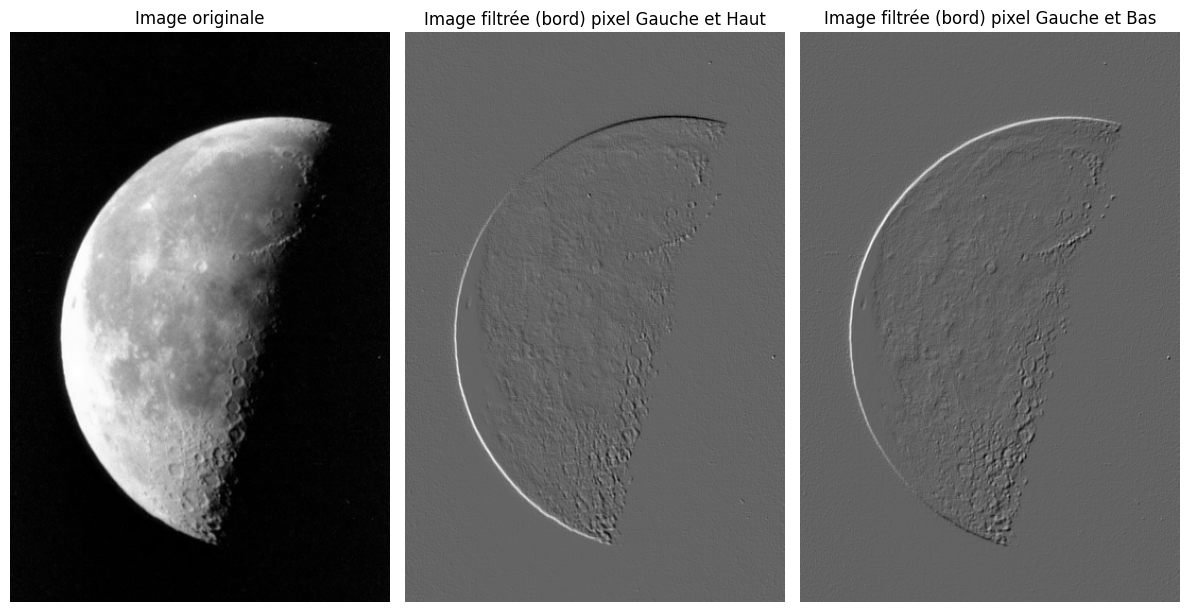

In [12]:
# 1. Import de l'image
MoonImg = '../Fichiers-pour-TP/Image/moon.tif'
moon = plt.imread(MoonImg)

# 2. Convertir l'image en niveaux de gris si elle est en couleur
if len(moon.shape) == 3:  # Vérifie si l'image est en couleur
    moon_gray = color.rgb2gray(moon)
    moon_gray = moon_gray.astype(float) / 255
else:
    moon_gray = moon.copy()

# 3. Définir la matrice de convolution 'h'
h1 = np.array([
    [0, -1, 0],
    [1,  0, 0],
    [0,  0, 0]
])

h2 = np.array([
    [0,  0, 0],
    [1,  0, 0],
    [0, -1, 0]
])

# 4. Appliquer la convolution avec le filtre 'h'
filtered_image1 = convolve2d(moon_gray, h1, mode='same', boundary='symm')
filtered_image2 = convolve2d(moon_gray, h2, mode='same', boundary='symm')

# 5. Afficher le résultat
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.imshow(moon_gray, cmap='gray')
plt.title("Image originale")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(filtered_image1, cmap='gray')
plt.title("Image filtrée (bord) pixel Gauche et Haut")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(filtered_image2, cmap='gray')
plt.title("Image filtrée (bord) pixel Gauche et Bas")
plt.axis('off')

plt.tight_layout()
plt.show()

#### 2) Filtre détection de bords

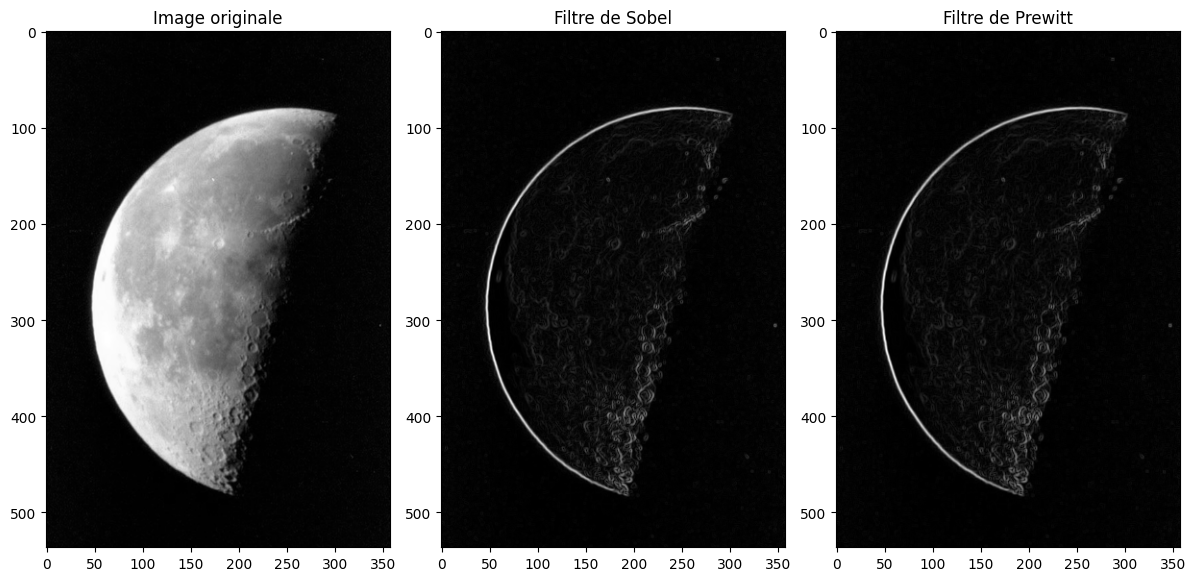

In [ ]:
# Filtrage
moon_gray_sobel   = filters.sobel(moon_gray)
moon_gray_prewitt = filters.prewitt(moon_gray)

# Afficher les résultats
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(moon_gray, cmap='gray')
axes[0].set_title("Image originale")

axes[1].imshow(moon_gray_sobel, cmap='gray')
axes[1].set_title("Filtre de Sobel")

axes[2].imshow(moon_gray_prewitt, cmap='gray')
axes[2].set_title("Filtre de Prewitt")

plt.tight_layout()
plt.show()

   Constatez les différences entre ces deux résultats.
   
   - La matrice `h` correspondant au filtre de Sobel est
   $$h=\left(
   \begin{array}{r r r}
   1&2&1\\
   0&0&0\\
   -1&-2&-1
   \end{array}
   \right).$$
On constate que, pour le filtrage d'un pixel, seuls les pixels des lignes supérieure et inférieure sont pris en compte. Si le pixel à remplacer est le pixel de valeur $I_{ij}$ (où $i$ représente l'indice de la ligne et $j$, l'indice de la colonne), donnez la formule de la valeur de ce pixel après filtrage.
- Essayez l'instruction `signal.convolve2d(I, h, mode='same')` et interprétez les résultats obtenus.

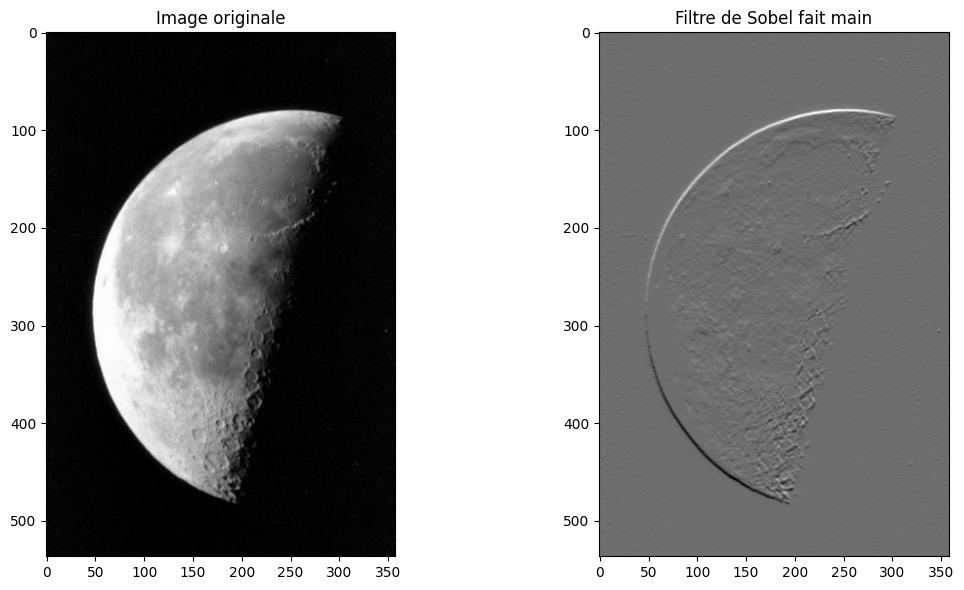

In [18]:
# Matrice de Convolution 'h'
h3 = np.array([
    [1,  2, 1],
    [0,  0, 0],
    [-1, -2, -1]
])

# Filtrage
filtered_image3 = convolve2d(moon_gray, h3, mode='same', boundary='symm')

# Afficher les résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(moon_gray, cmap='gray')
axes[0].set_title("Image originale")

axes[1].imshow(filtered_image3, cmap='gray')
axes[1].set_title("Filtre de Sobel fait main")

plt.tight_layout()
plt.show()

### 4.3 Opérations sur une image binaire

La fonction `measure.label` permet de réaliser un nombre très important d'opérations sur les images binaires via la « labelisation » de l'image.
Cette opération consiste à repérer les objets non connexes de l'image puis à numéroter tous les pixels de chaque objet par un même nombre. 
En comptant le nombre de pixels par objet, on peut en déduire sa surface. On peut également avoir accès à d'autres propriétés de ceux-ci : centre de gravité, excentricité, etc.
La fonction `measure.regionprops` donne accès à ces propriétés.
Voici un exemple de son utilisation sur une image binaire labelisée `L` :

In [ ]:
regions = measure.regionprops(L)

eccentricity_L = [props.eccentricity for props in regions]
area_L         = [props.area         for props in regions]

**Exercice 4.13** Ouvrez l'image `albireo.bmp`.

- **1)** Transformez cette image en image binaire au moyen de l'instruction`color.rgb2gray` suivie d'un seuil manuel (`> 0.5`). Affichez le résultat et constatez qu'un des objets a disparu.
- **2)** Résolvez le problème précédent en choisissant un seuil adéquat (utilisez la fonction `filters.threshold_otsu`).
- **3)** Définissez les objets présents et leur nombre au moyen de la fonction `measure.label`. Vérifiez que deux objets sont bien identifiés. La fonction `measure.label` attribue à tous les pixels d'un même objet un même nombre entier (qui commence à 1).
- **4)** Utilisez la fonction `measure.regionprops` pour accéder aux propriétés des objets. Celle-ci vous renverra une liste `regions`. `props.area for props in regions` renvoie un vecteur contenant la surface de chaque objet (en nombre de pixels).
- **5)** Identifiez automatiquement le label de l'objet ayant la plus grande surface.
- **6)** Affichez uniquement cet objet.
- **7)** Affichez côte à côte l'image initiale, l'image binaire correspondante et l'image finale. Vérifiez visuellement que celle-ci correspond bien à la condition demandée.

#### 1) Binarisation (simple)

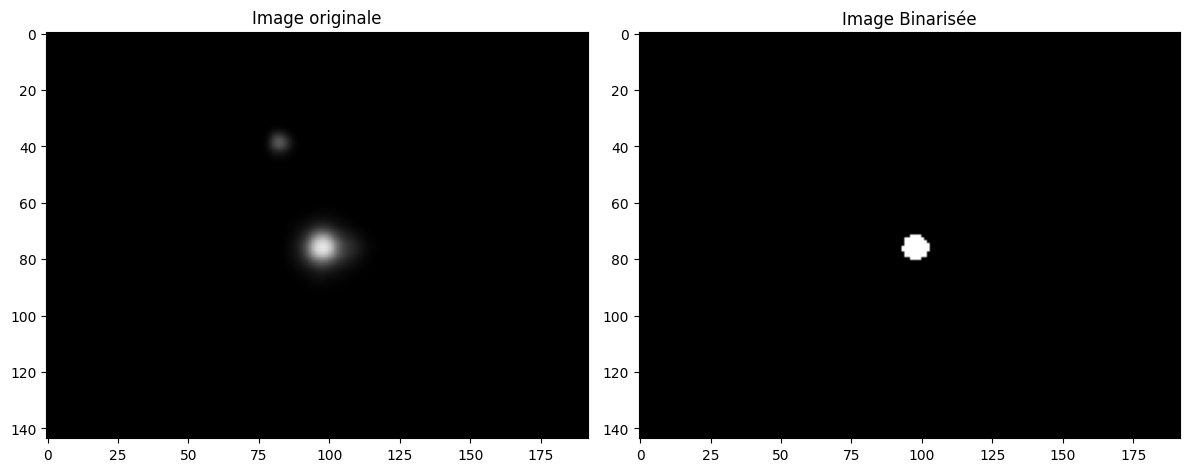

In [27]:
# 1. Import de l'image
AlbireoImg = '../Fichiers-pour-TP/Image/albireo.bmp'
albireo = plt.imread(AlbireoImg)

albireo_bin1 = color.rgb2gray(albireo) > 0.5

# Afficher les résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(albireo, cmap='gray')
axes[0].set_title("Image originale")

axes[1].imshow(albireo_bin1, cmap='gray')
axes[1].set_title("Image Binarisée")

plt.tight_layout()
plt.show()

#### 2) Binarisation (complexe)
##### **Explications :**
- `filters.threshold_otsu` retourne une valeur qui est un seuil.
- Ce seuil optimal est ajusté dynamiquement en fonction de l'histogramme de l'image en niveau de gris qui lui est passé.
- Cette fonction compare chaque pixel de l'image en niveaux de gris au seuil calculé. Les pixels au-dessus du seuil sont True (blanc en affichage) et ceux en dessous sont False (noir en affichage).

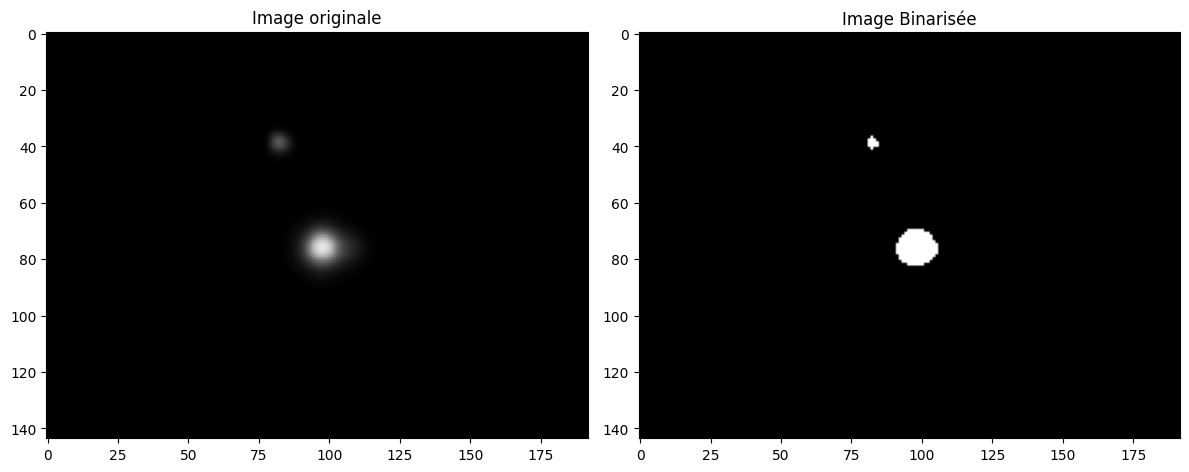

In [28]:
albireo_gray = color.rgb2gray(albireo)  # Convertir en niveaux de gris si nécessaire

# Calcul du seuil avec la méthode d'Otsu
threshold = filters.threshold_otsu(albireo_gray)

# Binarisation de l'image en utilisant le seuil
albireo_bin2 = albireo_gray > threshold

# Afficher les résultats
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(albireo, cmap='gray')
axes[0].set_title("Image originale")

axes[1].imshow(albireo_bin2, cmap='gray')
axes[1].set_title("Image Binarisée")

plt.tight_layout()
plt.show()

#### 3) Labelisation (simple)

In [30]:
labels, number_of_labels = measure.label(albireo_bin2, return_num=True)

print(f"Ce que contient les Labels : {labels}")
print(f"Le nombre de Labels : {number_of_labels}")

Ce que contient les Labels : [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Le nombre de Labels : 2


#### 4) Surface de chaque objet (en pixel)

In [36]:
regions = measure.regionprops(labels)

# for i in regions :
#     print(f"La surface de chacun des objets : {i}")

area_L = [props.area for props in regions]

print(f"La surface de chacun des objets : {area_L}")

La surface de chacun des objets : [np.float64(13.0), np.float64(152.0)]


#### 5), 6) et 7) Identifier Label avec la pus grande Surface, l'afficher et afficher l'image originale ainsi que Binarisée

Le label de l'objet ayant la plus grande surface est : 2
La surface maximale est : 152.0


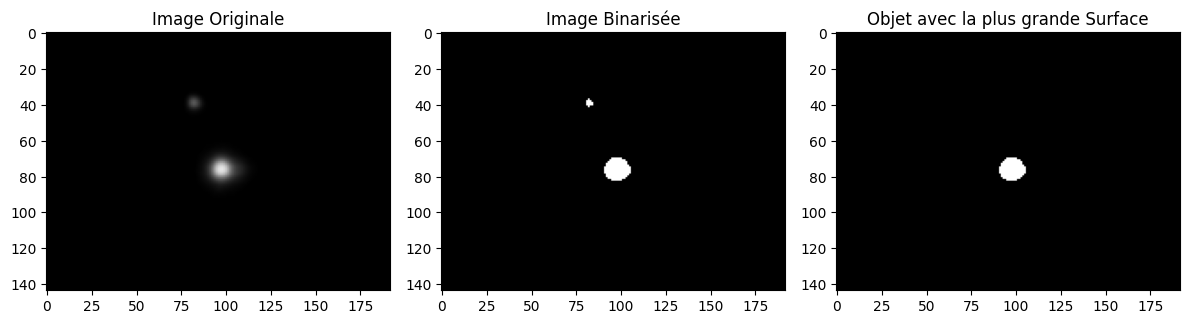

In [41]:
# Supposons que votre image binarisée soit "albireo_bin"
# Étape 1 : Labelliser les objets

# Étape 2 : Calculer les propriétés des objets

# Étape 3 : Identifier le label de l'objet ayant la plus grande surface
max_area = 0
largest_label = None

for region in regions:
    if region.area > max_area:
        max_area = region.area
        largest_label = region.label

# Afficher le résultat
print(f"Le label de l'objet ayant la plus grande surface est : {largest_label}")
print(f"La surface maximale est : {max_area}")

# Afficher l'image avec le label le plus grand mis en évidence
highlighted = np.where(labels == largest_label, 1, 0)

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes[0].imshow(albireo, cmap='gray')
axes[0].set_title("Image Originale")

axes[1].imshow(albireo_bin2, cmap='gray')
axes[1].set_title("Image Binarisée")

axes[2].imshow(highlighted, cmap='gray')
axes[2].set_title("Objet avec la plus grande Surface")

plt.tight_layout()
plt.show()

**Exercice 4.14** Ouvrez l'image `circuit1.tif` et constatez que l'image comporte de petites taches. Utilisez la fonction `measure.label` pour parvenir à les éliminer.

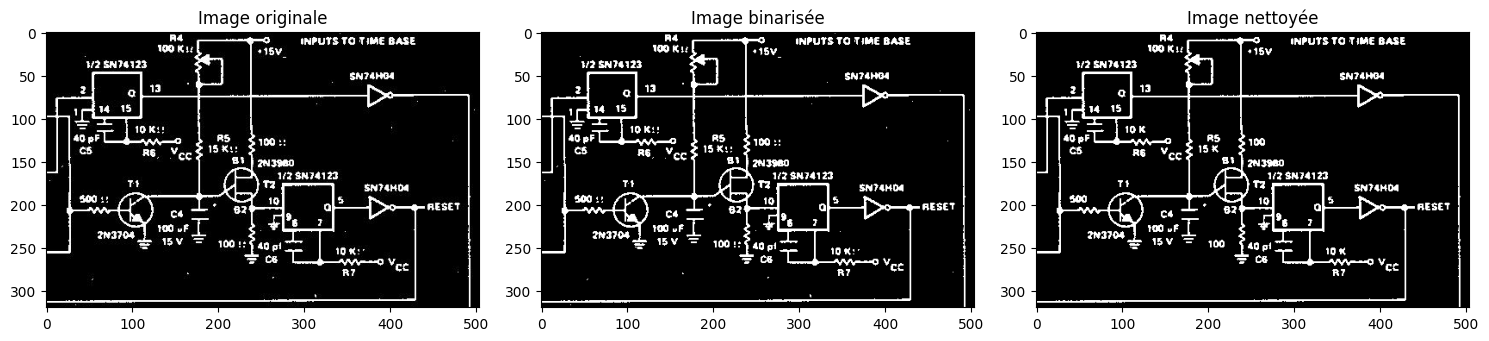

In [49]:
# Charger l'image
CircuitImg = '../Fichiers-pour-TP/Image/circuit1.tif'
circuit = plt.imread(CircuitImg)

# Transformer l'image en niveau de gris
circuit_gray = color.rgb2gray(circuit)  # Convertir en niveaux de gris si nécessaire
# circuit_gray = (circuit / 255).astype(np.float64)

# Binariser l'image (si nécessaire)
# Supposons que `circuit` est déjà en niveaux de gris
circuit_bin = circuit_gray > 0.5  # Seuil pour binariser l'image
# circuit_bin = circuit > 128  # Seuil pour binariser l'image

# Labelliser les objets
labels2 = measure.label(circuit_bin)

# Calculer les propriétés des régions
regions2 = measure.regionprops(labels2)

# Définir un seuil de taille (par exemple, 50 pixels)
size_threshold = 10

# Supprimer les petites régions
cleaned_labels = np.copy(labels2)
for region in regions2:
    if region.area < size_threshold:
        cleaned_labels[labels2 == region.label] = 0

# Convertir en image binaire après nettoyage
circuit_cleaned = cleaned_labels > 0

# Afficher les résultats
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(circuit, cmap='gray')
axes[0].set_title("Image originale")

axes[1].imshow(circuit_bin, cmap='gray')
axes[1].set_title("Image binarisée")

axes[2].imshow(circuit_cleaned, cmap='gray')
axes[2].set_title("Image nettoyée")

plt.tight_layout()
plt.show()

**Exercice 4.15** Considérons l'image `label_exc.jpg`. On souhaite détecter les objets allongés de l'image. Procédez de la même manière que dans l'exercice 4.13 mais utilisez plutôt la propriété d'excentricité (`eccentricity`). Il faut également inverser l'image binaire avant de la labeliser. Ne pas le faire impliquerait de n'avoir qu'un seul objet : le <i>background</i>.  

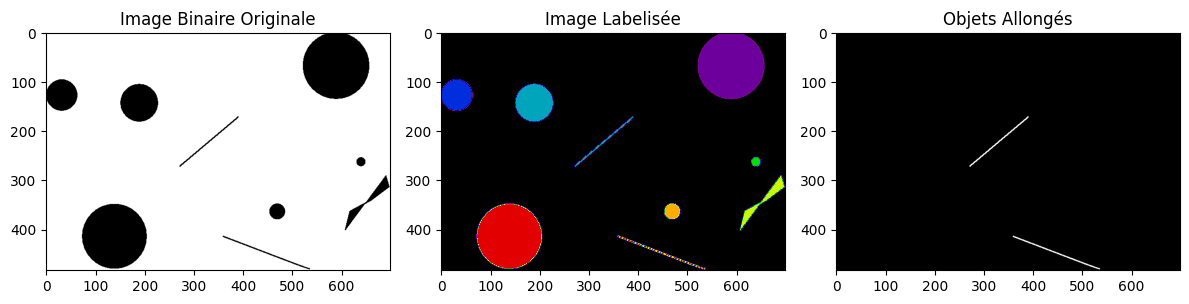

In [68]:
# Charger l'image
Circles_and_Lines_Img = '../Fichiers-pour-TP/Image/bwlabel_exc.jpg'
circles_and_lines = plt.imread(Circles_and_Lines_Img)

# Coversion en niveau de gris
if circles_and_lines.ndim == 3:
    circles_and_lines = color.rgb2gray(circles_and_lines)

# Binarisation de l'image
threshold = filters.threshold_otsu(circles_and_lines)
circles_and_lines_bin = circles_and_lines > threshold

# Inverser l'image binaire pour que les objets soient en blanc
circles_and_lines_inverted = ~circles_and_lines_bin

# Labeliser les objets
labeled_circles_and_lines_inverted = measure.label(circles_and_lines_inverted, connectivity=2)

# Obtenir les propriétés des objets
regions = measure.regionprops(labeled_circles_and_lines_inverted)

# Créer une nouvelle image binaire pour les objets allongés
elongated_objects = morphology.remove_small_objects(labeled_circles_and_lines_inverted, min_size=10) * 0  # Init image vide

# Filtrer les objets par excentricité (ex. > 0.8 pour détecter les objets allongés)
for region in regions:
    if region.eccentricity > 0.999:  # Critère d'allongement
        elongated_objects[labeled_circles_and_lines_inverted == region.label] = 1

# Visualiser les résultats
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

axes[0].imshow(circles_and_lines_bin, cmap='gray')
axes[0].set_title("Image Binaire Originale")

axes[1].imshow(labeled_circles_and_lines_inverted, cmap='nipy_spectral')
axes[1].set_title("Image Labelisée")

axes[2].imshow(elongated_objects, cmap='gray')
axes[2].set_title("Objets Allongés")

plt.tight_layout()
plt.show()

##### **Explications :**
- `Excentricité` : 
  - Utilisée pour détecter les formes allongées, ce qui n'est pas possible avec la surface seule.
  - L'excentricité est une mesure géométrique qui caractérise la forme d'un objet en fonction de sa ressemblance avec une ellipse. Elle est définie mathématiquement comme suit :

    - Excentricité = Racine de (1−𝑏^2 / 𝑎^2)
    - 𝑎 : demi-grand axe de l'ellipse équivalente.
    - 𝑏 : demi-petit axe de l'ellipse équivalente.
  - La valeur d'excentricité varie entre :
    - 0 : pour un cercle parfait (𝑎 = 𝑏).
    - 1 : pour une ligne parfaitement allongée (𝑏→0).
  - Dans le cadre de cet exercice, les objets "allongés" auront une excentricité proche de 1.  
- `Inversion de l'image` : Permet de transformer les objets en régions séparées en blanc (1) dans un fond noir (0), ce qui facilite la détection et l'analyse des objets via `measure.label`.